# 📊 EDA — ESA Satellite Training SOC Dataset

**File:** `esa_eo4_train_soc.csv`  
**Rows:** 23,898 | **Columns:** 227  
**Description:** Earth-observation satellite features for predicting Soil Organic Carbon (SOC). Contains bioclimatic variables, vegetation indices, terrain features, land cover, snow probability, and spectral bands across 6 bi-monthly seasons.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [3]:
from pathlib import Path
raw = Path('../data/raw')
df = pd.read_csv(raw / 'esa_eo4_train_soc.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (23898, 227)


,olc_id,UUID,X,Y,observation_year,hzn_top,hzn_bot,bioclim.var_chelsa.bio12_m_1km_s_1981_2010_go_epsg.4326_v20231002,bioclim.var_chelsa.bio13_m_1km_s_1981_2010_go_epsg.4326_v20231002,bioclim.var_chelsa.bio16_m_1km_s_1981_2010_go_epsg.4326_v20231002,...,wetlands.cw_upmc.wtd_c_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.groundwater-driven_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.permanent_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.regularly-flooded_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wv_mcd19a2v061.seasconv.m.yearly_p25_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_p50_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_p75_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_sd_1km_s_0101_1231_go_epsg.4326_v20230619,sample_id,logoc_d.f
0,87QJ79FW+W38,b1815dfa-b862-11ee-843e-0242ac110004,2.193808e+06,2.806497e+06,2017,10,40,12466,1287,3769,...,0,0,0,0,506,1054,2020,755,84019,5.220388
1,87RJP2G3+6FV,b17f3ef8-b862-11ee-843e-0242ac110004,2.117680e+06,2.951602e+06,2012,0,10,10606,1081,3088,...,0,0,0,0,504,1035,1538,680,58825,3.335679
2,87PHW8F8+9M6,b17f42ae-b862-11ee-843e-0242ac110004,2.123917e+06,2.744570e+06,2012,3,8,11285,1189,3333,...,0,0,0,0,565,1030,1694,742,96207,3.887080
3,87QHQ3RV+JMH,b17eca9a-b862-11ee-843e-0242ac110004,2.079950e+06,2.832242e+06,2010,18,24,11800,1183,3428,...,3,0,50,50,493,958,1591,731,97127,2.100720
4,87RHG7CP+H42,b17e5808-b862-11ee-843e-0242ac110004,2.071283e+06,2.914094e+06,2009,6,21,12825,1303,3775,...,0,31,0,0,412,519,1147,552,66739,3.939469


## 2. Basic Information


In [4]:
df.info(verbose=False, show_counts=True)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23898 entries, 0 to 23897
Columns: 227 entries, olc_id to logoc_d.f
dtypes: float64(3), int64(222), object(2)
memory usage: 41.4+ MB

Memory usage: 46.9 MB


In [5]:
df.describe().T.head(20)


,count,mean,std,min,25%,50%,75%,max
X,23898.0,-4.773692e+05,1.275797e+06,-2.349668e+06,-1.892329e+06,-3.179114e+05,5.259672e+05,2.255345e+06
Y,23898.0,2.015376e+06,5.475784e+05,2.992725e+05,1.666952e+06,2.001073e+06,2.413438e+06,3.134435e+06
observation_year,23898.0,2.010671e+03,5.320207e+00,2.001000e+03,2.006000e+03,2.011000e+03,2.015000e+03,2.020000e+03
hzn_top,23898.0,4.897853e+01,6.027348e+01,0.000000e+00,8.000000e+00,3.200000e+01,7.500000e+01,1.564000e+03
hzn_bot,23898.0,7.379283e+01,6.862599e+01,4.000000e+00,2.500000e+01,5.700000e+01,1.060000e+02,1.628000e+03
bioclim.var_chelsa.bio12_m_1km_s_1981_2010_go_epsg.4326_v20231002,23898.0,9.521251e+03,5.107769e+03,7.210000e+02,5.487000e+03,8.972000e+03,1.243200e+04,4.023300e+04
bioclim.var_chelsa.bio13_m_1km_s_1981_2010_go_epsg.4326_v20231002,23898.0,1.384636e+03,8.830674e+02,1.230000e+02,9.010000e+02,1.189000e+03,1.462000e+03,6.286000e+03
bioclim.var_chelsa.bio16_m_1km_s_1981_2010_go_epsg.4326_v20231002,23898.0,3.762447e+03,2.364160e+03,3.150000e+02,2.458000e+03,3.317000e+03,4.033000e+03,1.848300e+04
bioclim.var_chelsa.bio2_m_1km_s_1981_2010_go_epsg.4326_v20231002,23898.0,1.059211e+02,2.080317e+01,1.200000e+01,9.400000e+01,1.040000e+02,1.220000e+02,1.590000e+02
bioclim.var_chelsa.bio3_m_1km_s_1981_2010_go_epsg.4326_v20231002,23898.0,3.266910e+02,7.581383e+01,1.110000e+02,2.720000e+02,3.220000e+02,3.810000e+02,5.330000e+02


In [6]:
print("Dtype counts:")
print(df.dtypes.value_counts())
print(f"\nObject columns: {df.select_dtypes('object').columns.tolist()}")
print(f"\nTarget column: 'logoc_d.f' — log-transformed organic carbon")
print(f"Target stats:\n{df['logoc_d.f'].describe()}")


Dtype counts:
int64      222
float64      3
object       2
Name: count, dtype: int64

Object columns: ['olc_id', 'UUID']

Target column: 'logoc_d.f' — log-transformed organic carbon
Target stats:
count    23898.000000
mean         2.492761
std          1.022049
min          0.000000
25%          1.717395
50%          2.429437
75%          3.186353
max          6.424869
Name: logoc_d.f, dtype: float64


## 3. Missing Values Analysis


In [7]:
missing = df.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print("✅ No missing values in any column!")
else:
    missing_cols = missing[missing > 0].sort_values(ascending=False)
    print(f"Columns with missing values: {len(missing_cols)}")
    print(missing_cols)


✅ No missing values in any column!


## 4. Target Variable Distribution


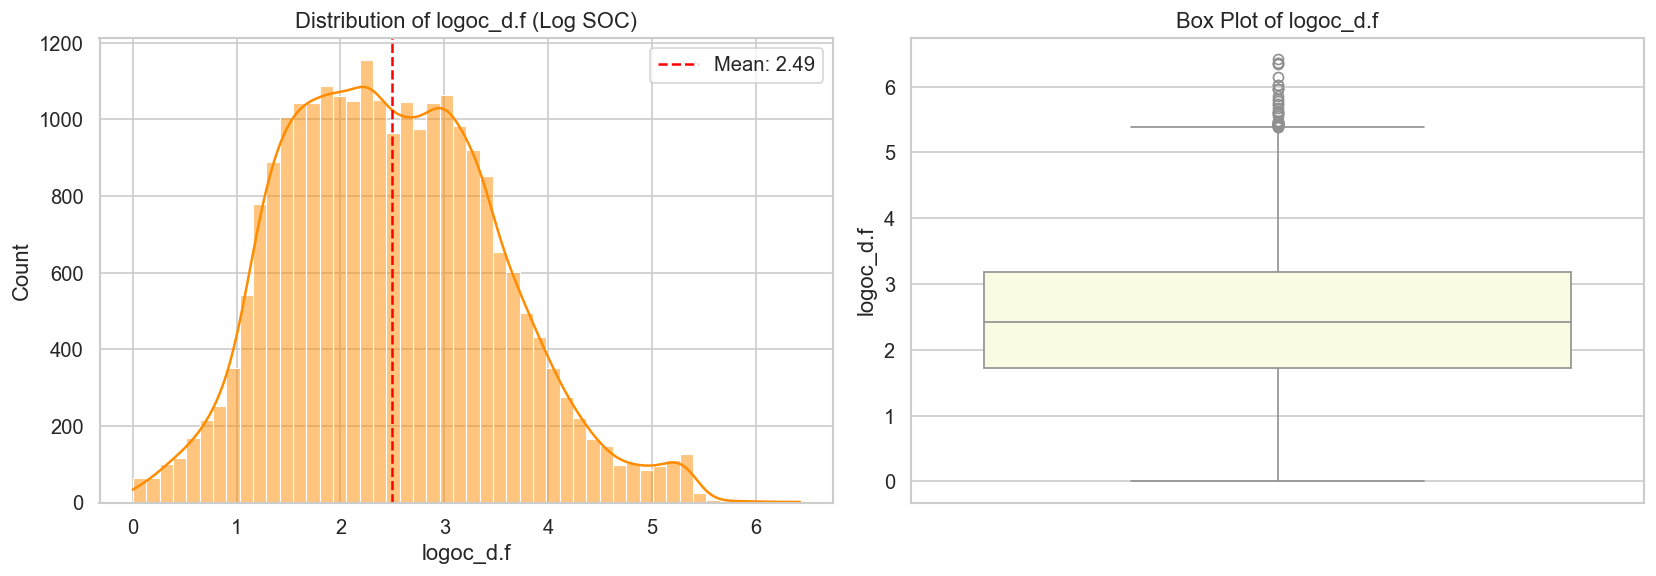

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['logoc_d.f'], kde=True, bins=50, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of logoc_d.f (Log SOC)')
axes[0].axvline(df['logoc_d.f'].mean(), color='red', ls='--', label=f"Mean: {df['logoc_d.f'].mean():.2f}")
axes[0].legend()

sns.boxplot(y=df['logoc_d.f'], ax=axes[1], color='lightyellow')
axes[1].set_title('Box Plot of logoc_d.f')

plt.tight_layout()
plt.show()


## 5. Feature Groups Analysis

With 227 columns, we group features by prefix to understand them.


In [9]:
# Group columns by prefix
feature_cols = [c for c in df.columns if c not in ['olc_id', 'UUID', 'sample_id', 'logoc_d.f']]

prefixes = {}
for col in feature_cols:
    prefix = col.split('_')[0] if '_' in col else col
    prefixes.setdefault(prefix, []).append(col)

print(f"Total feature groups: {len(prefixes)}\n")
for k, v in sorted(prefixes.items(), key=lambda x: -len(x[1])):
    print(f"  {k:30s}: {len(v)} features")


Total feature groups: 61

  snow.prob                     : 24 features
  dtm                           : 16 features
  clm                           : 9 features
  blue                          : 6 features
  bsi                           : 6 features
  evi                           : 6 features
  fapar                         : 6 features
  green                         : 6 features
  msavi                         : 6 features
  nbr2                          : 6 features
  nbr                           : 6 features
  ndmi                          : 6 features
  ndsi                          : 6 features
  ndsmi                         : 6 features
  ndti                          : 6 features
  ndvi                          : 6 features
  ndwi                          : 6 features
  nir                           : 6 features
  nirv                          : 6 features
  red                           : 6 features
  savi                          : 6 features
  swir1                    

## 6. Spatial Distribution


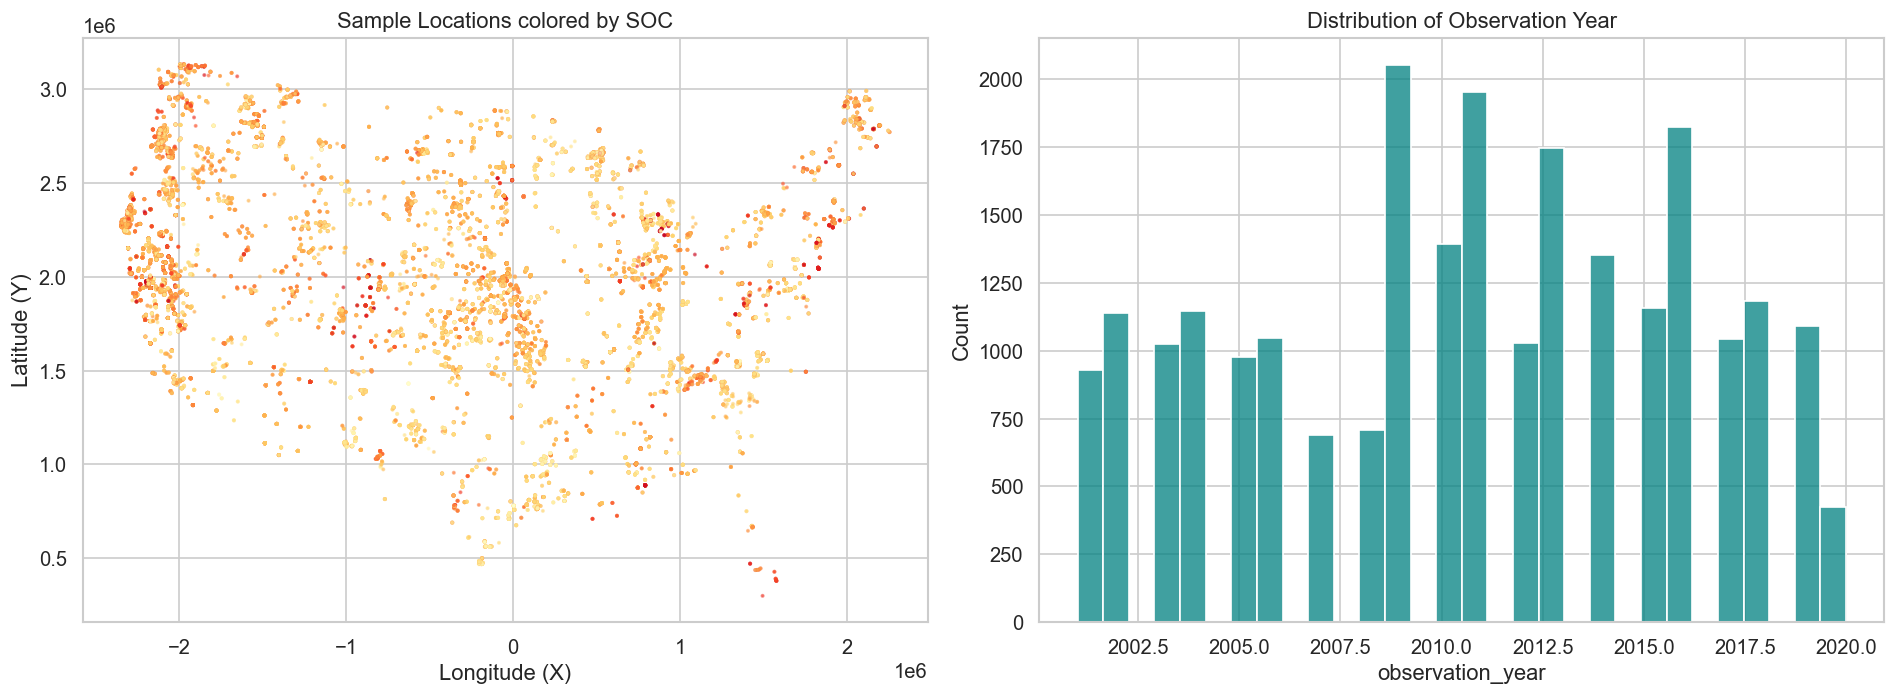

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['X'], df['Y'], c=df['logoc_d.f'], cmap='YlOrRd', s=2, alpha=0.5)
axes[0].set_title('Sample Locations colored by SOC')
axes[0].set_xlabel('Longitude (X)')
axes[0].set_ylabel('Latitude (Y)')

sns.histplot(data=df, x='observation_year', bins=30, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Observation Year')

plt.tight_layout()
plt.show()


## 7. Correlation with Target


Top 15 features correlated with logoc_d.f:

hzn_bot                                                             -0.484713
hzn_top                                                             -0.443457
clm_lst_mod11a2.nighttime_p95_1km_s0..0cm__v1.2                     -0.201786
swir1_glad.SeasConv.ard2_m_30m_s_0501_0630_go_epsg.4326_v20230908   -0.195964
swir1_glad.SeasConv.ard2_m_30m_s_0101_0228_go_epsg.4326_v20230908   -0.193007
swir1_glad.SeasConv.ard2_m_30m_s_0301_0430_go_epsg.4326_v20230908   -0.189359
slope_merit.dem_m_250m_s0..0cm_2017_2017_go_epsg.4326_v20231002      0.185736
Y                                                                    0.180919
swir2_glad.SeasConv.ard2_m_30m_s_0101_0228_go_epsg.4326_v20230908   -0.180623
swir2_glad.SeasConv.ard2_m_30m_s_0501_0630_go_epsg.4326_v20230908   -0.177441
swir1_glad.SeasConv.ard2_m_30m_s_1101_1231_go_epsg.4326_v20230908   -0.177131
swir1_glad.SeasConv.ard2_m_30m_s_0901_1031_go_epsg.4326_v20230908   -0.172842
swir2_glad.SeasConv.

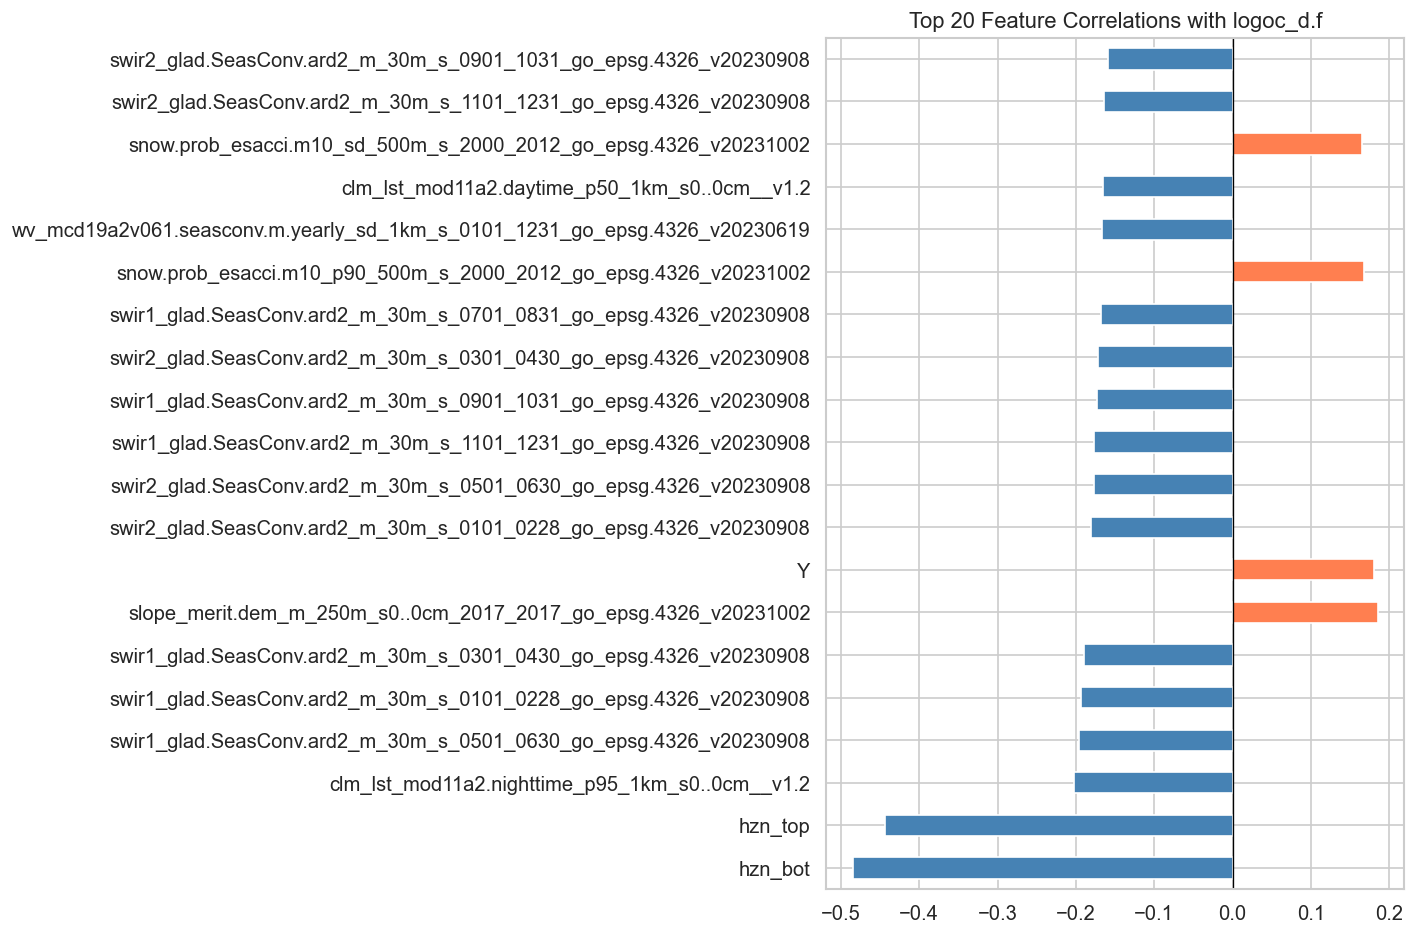

In [11]:
# Compute correlations of all numeric features with target
target = 'logoc_d.f'
numeric_df = df.select_dtypes(include=np.number).drop(columns=['sample_id'], errors='ignore')
corrs = numeric_df.corr()[target].drop(target).sort_values(key=abs, ascending=False)

print(f"Top 15 features correlated with {target}:\n")
print(corrs.head(15).to_string())
print(f"\nBottom 15 features correlated with {target}:\n")
print(corrs.tail(5).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
corrs.head(20).plot(kind='barh', ax=ax, color=['coral' if x > 0 else 'steelblue' for x in corrs.head(20)])
ax.set_title(f'Top 20 Feature Correlations with {target}')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()


## 8. Vegetation Index Seasonal Patterns


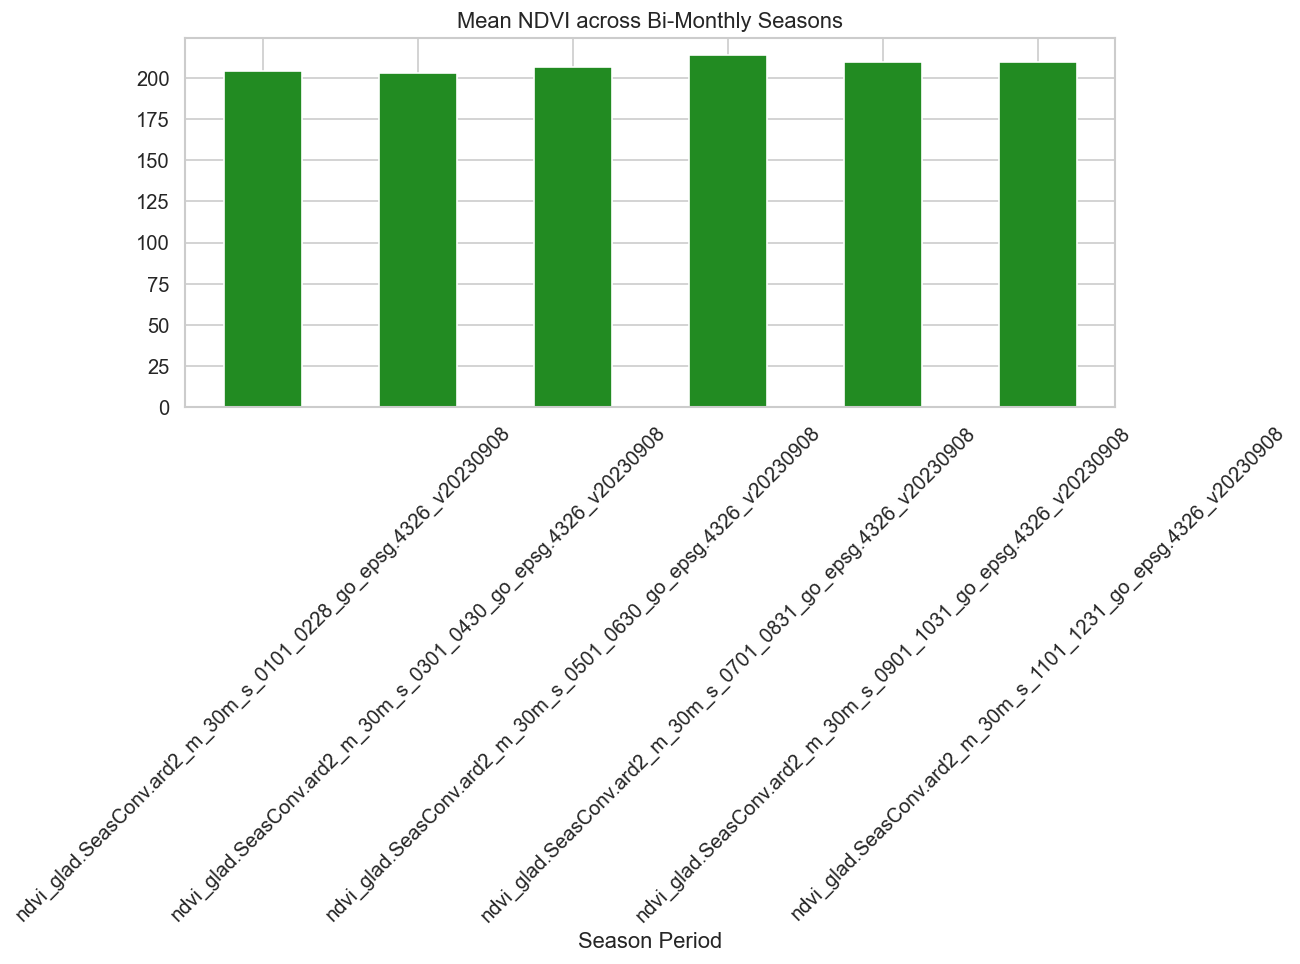

In [12]:
# NDVI across seasons
ndvi_cols = [c for c in df.columns if c.startswith('ndvi_')]
if ndvi_cols:
    ndvi_means = df[ndvi_cols].mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ndvi_means.plot(kind='bar', ax=ax, color='forestgreen')
    ax.set_title('Mean NDVI across Bi-Monthly Seasons')
    ax.set_xlabel('Season Period')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Soil Depth Analysis


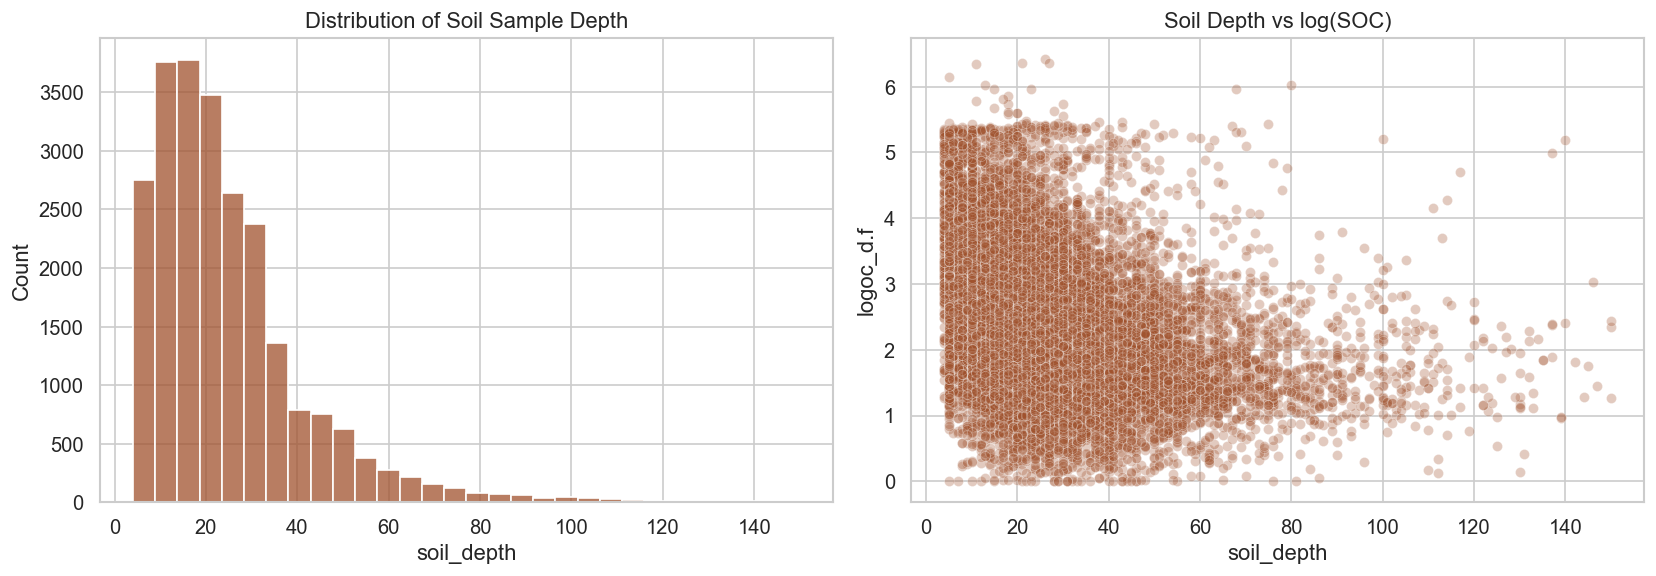

In [13]:
if 'hzn_top' in df.columns and 'hzn_bot' in df.columns:
    df['soil_depth'] = df['hzn_bot'] - df['hzn_top']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df['soil_depth'], bins=30, ax=axes[0], color='sienna')
    axes[0].set_title('Distribution of Soil Sample Depth')
    
    sns.scatterplot(data=df, x='soil_depth', y='logoc_d.f', alpha=0.3, ax=axes[1], color='sienna')
    axes[1].set_title('Soil Depth vs log(SOC)')
    
    plt.tight_layout()
    plt.show()


## 10. Feature Correlation Heatmap (Top Features)


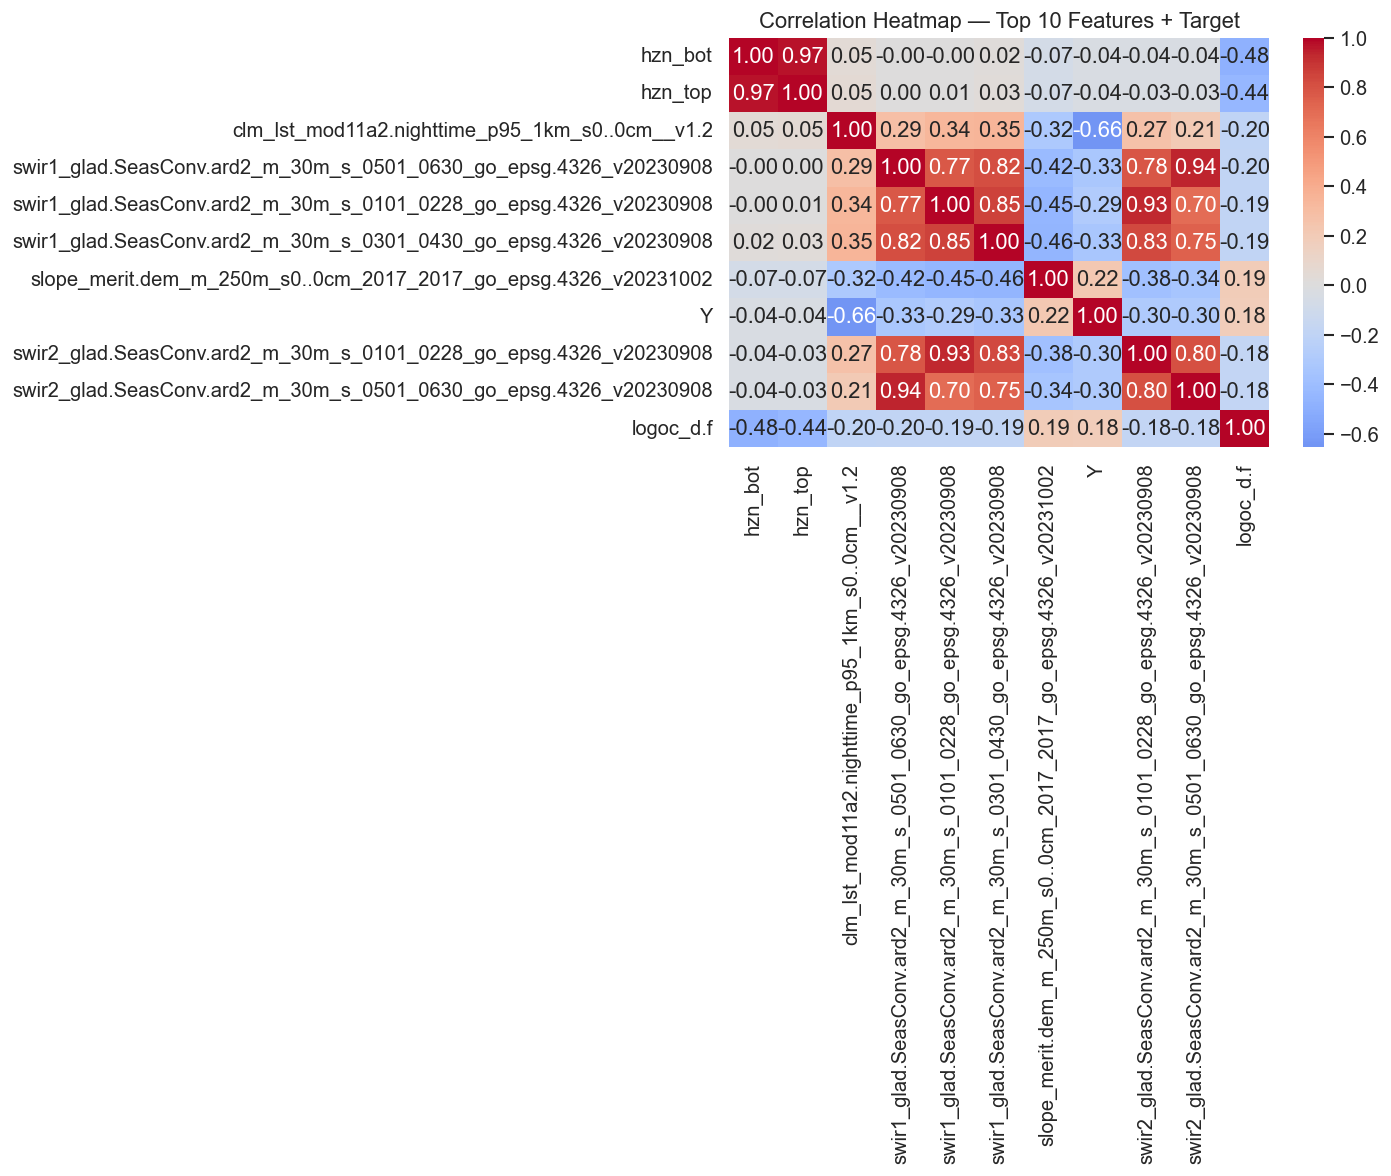

In [14]:
top_feats = corrs.head(10).index.tolist() + [target]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Top 10 Features + Target')
plt.tight_layout()
plt.show()


## 11. Key Findings & Summary

### Dataset Summary
- **23,898 rows × 227 columns** with **zero missing values**
- Target: `logoc_d.f` (log-transformed soil organic carbon)
- ID columns: `olc_id`, `UUID`, `sample_id`
- 222 integer features, 3 float features, 2 object columns

### Key Observations
1. **High-dimensional**: 220+ remote-sensing & geospatial features
2. **Seasonal structure**: Many features repeat across 6 bi-monthly periods (Jan–Feb, Mar–Apr, …)
3. **Spatial data**: X/Y coordinates allow geographic analysis
4. **Feature groups**: Vegetation indices (NDVI, EVI, FAPAR, SAVI, etc.), spectral bands (blue, green, red, NIR, SWIR), terrain, climate, snow, lithology, landform, wetlands
5. **Target distribution**: Approximately normal (log-transformed)

### Recommendations for Modelling
- Consider PCA or feature selection to reduce dimensionality
- Leverage seasonal patterns via aggregation (mean/std across seasons)
- Spatial cross-validation recommended (avoid data leakage from nearby points)
- Tree-based models (XGBoost, LightGBM) may handle the high dimensionality well
